# `^{171}\mathrm{Yb}` UV thermal blockade-noise response

This notebook is the first notebook-first development record for the effect of thermal position and velocity fluctuations on the current `^{171}\mathrm{Yb}` UV controlled-Z segment. It keeps the already optimized Gaussian-edge time-optimal phase sequence fixed and scans the blockade shift. No UV phase sequence reoptimization is performed in the executed path.

The thermal formulas are written as explicit functions of temperature `T`. The reported `\bar n=0.25(10)` from the PRX Quantum experiment is used only to infer a reference oscillator temperature, not as the primary variable. This avoids hiding the temperature dependence inside a fixed motional occupation number.

The reported process fidelity is phase-corrected at each blockade value: for a fixed UV pulse, the branch phases `alpha,beta` are refit before evaluating the restricted CZ process fidelity. The fully fixed nominal-virtual-Z value is retained only as a diagnostic column in the saved data.


## Source verification and scope

| Source | Verification status | Used facts | Role in this notebook |
|---|---|---|---|
| Muniz et al., *PRX Quantum* **6**, 020334 (2025), DOI `10.1103/PRXQuantum.6.020334`; arXiv `2411.11708v2` | Verified against the APS abstract page and the arXiv PDF. | `^{171}\mathrm{Yb}` nuclear-spin CZ gate; UV wavelength `301.9 nm`; `|65\,^3S_1,F=3/2,m_F=-3/2\rangle`; pair spacing `3 um`; science trap frequency `50 kHz`; cooling result `\bar n=0.25(10)`; `U/h=160 MHz`; Rydberg lifetime `65(3) us`; `T_2^*=3.4(2) us`. | Primary experimental conditions. `\bar n` is used only to infer one reference temperature. |
| Li, Qian, and Zhang, *New Journal of Physics* **27**, 054502 (2025), DOI `10.1088/1367-2630/adcfbe` | Read from Zotero item `IK4SLCXW` with PDF attachment `CCXS3N3C`; official DOI metadata checked through IOP/NJP. | Doppler dephasing model `\delta=\mathbf{k}\cdot\mathbf{v}`, Rydberg detuning term `-\delta |r\rangle\langle r|`, independent one-dimensional Gaussian velocities, and the warning that Doppler dephasing is a dominant motional error unless specially erased. | Doppler-noise derivation and scale estimate as explicit functions of `T`. |
| Saffman, *J. Phys. B* **49**, 202001 (2016), DOI `10.1088/0953-4075/49/20/202001`; arXiv `1605.05207` | Verified through arXiv record and DOI link. | Rydberg-mediated gate context and van der Waals blockade model. | Cross-check that using a local `C_6/R^6` blockade law is the standard first model. |
| Jandura and Pupillo, *Quantum* **6**, 712 (2022), DOI `10.22331/q-2022-05-13-712`; arXiv `2202.00903` | Verified through arXiv and DOI search. | Time-optimal GRAPE/Pontryagin Rydberg CZ context. | Motivation for keeping the optimized phase sequence as the object being tested. |

Scope boundary: this notebook estimates thermal blockade and Doppler noise under the published PRX Quantum 6, 020334 operating conditions. It does not claim a full experimental error budget, because the paper also identifies UV phase noise, clock errors, leakage/loss, and calibration drift.


## Thermal blockade variation as an explicit function of temperature

The experimental geometry provides the constants:

- pair spacing in the Rydberg interaction zone: `R_0 = 3 um`;
- science-trap angular frequency: `\omega_\mathrm{sci}=2\pi\times 50 kHz`;
- nominal Rydberg interaction energy: `B_0/h=160 MHz`.

Instead of inserting a fixed `\bar n` into the main formula, use the classical thermal spatial distribution at temperature `T`. For one atom in a harmonic trap,

$$
\sigma_x^2(T)=\frac{k_B T}{m\omega_\mathrm{sci}^2}.
$$

For two independent atoms along the interatomic axis,

$$
q=x_2-x_1,\qquad
\sigma_q(T)=\sqrt{2}\,\sigma_x(T)
=\sqrt{\frac{2k_B T}{m\omega_\mathrm{sci}^2}}.
$$

The van der Waals blockade is

$$
B(R)=B_0\left(\frac{R_0}{R}\right)^6,\qquad R=R_0+q.
$$

Expanding around `q=0`,

$$
\frac{B(R)}{B_0}
=\left(1+\frac{q}{R_0}\right)^{-6}
\simeq
1-6\frac{q}{R_0}
+21\left(\frac{q}{R_0}\right)^2+O(q^3/R_0^3).
$$

Thus the leading RMS blockade fluctuation is

$$
\sigma_B(T)
\simeq
6B_0\frac{\sigma_q(T)}{R_0}
=
\frac{6B_0}{R_0}
\sqrt{\frac{2k_B T}{m\omega_\mathrm{sci}^2}}.
$$

With `m=171 amu`, `R_0=3 um`, `B_0/h=160 MHz`, and `\omega_\mathrm{sci}/2\pi=50 kHz`,

$$
\boxed{
\frac{\sigma_B(T)}{h}
=10.045\sqrt{T_{\mu\mathrm{K}}}\,\mathrm{MHz}
}
$$

where `T_{\mu\mathrm{K}}` is temperature in microkelvin.

### Optional reference temperature from the reported `\bar n`

For a harmonic oscillator in thermal equilibrium,

$$
\bar n(T)=\frac{1}{\exp(\hbar\omega_\mathrm{sci}/k_B T)-1},
$$

so

$$
T(\bar n)=
\frac{\hbar\omega_\mathrm{sci}}
{k_B\ln(1+1/\bar n)}.
$$

Using the reported `\bar n=0.25` gives

$$
T_\mathrm{ref}=1.49\,\mu\mathrm{K}.
$$

At this reference temperature,

$$
\sigma_x=27.1\,\mathrm{nm},\qquad
\sigma_q=38.3\,\mathrm{nm},\qquad
\sigma_B/h=12.27\,\mathrm{MHz}.
$$

The exact one-sigma endpoints obtained by substituting `q=\pm\sigma_q` into `B(R)` are

$$
B(R_0+\sigma_q)/h=148.3\,\mathrm{MHz},\qquad
B(R_0-\sigma_q)/h=172.8\,\mathrm{MHz}.
$$

Important distinction: the earlier `\left(\bar n+1/2\right)\hbar\omega` variance includes zero-point motion. That is the correct quantum oscillator variance, but it is not the same as Li et al.'s classical thermal velocity ensemble. For the present temperature-explicit noise estimate, the main variable is `T`; `\bar n` only supplies the optional reference value above.


In [1]:
from __future__ import annotations

import csv
import json
import math
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import expm
from scipy.optimize import minimize

print("imports ready")


imports ready


## Helper functions

The next cell contains small notebook-local helpers. Keeping them local makes the notebook readable as a development record; the packaging step, if approved later, can move stable pieces into `src/neutral_yb/`.


In [2]:
def wrap_phase(phases: np.ndarray | list[float]) -> np.ndarray:
    return (np.asarray(phases, dtype=np.float64) + np.pi) % (2.0 * np.pi) - np.pi


def unwrap_for_plot(phases: np.ndarray | list[float]) -> np.ndarray:
    return np.unwrap(np.asarray(phases, dtype=np.float64))


def gaussian_edge_envelope(
    num_slots: int,
    total_time_ns: float,
    edge_time_ns: float,
    sigma_to_edge: float = 1.0 / 3.0,
) -> np.ndarray:
    if edge_time_ns <= 0.0:
        return np.ones(int(num_slots), dtype=np.float64)
    duration = float(total_time_ns)
    edge = min(float(edge_time_ns), 0.499 * duration)
    grid = np.linspace(0.0, duration, int(num_slots), endpoint=True, dtype=np.float64)
    sigma = max(edge * float(sigma_to_edge), 1e-12)
    envelope = np.ones_like(grid)
    left = grid < edge
    right = grid > duration - edge
    edge_floor = np.exp(-0.5 * (edge / sigma) ** 2)
    if np.any(left):
        left_gaussian = np.exp(-0.5 * ((grid[left] - edge) / sigma) ** 2)
        envelope[left] = (left_gaussian - edge_floor) / max(1.0 - edge_floor, 1e-12)
    if np.any(right):
        right_gaussian = np.exp(-0.5 * ((grid[right] - (duration - edge)) / sigma) ** 2)
        envelope[right] = (right_gaussian - edge_floor) / max(1.0 - edge_floor, 1e-12)
    envelope[0] = 0.0
    envelope[-1] = 0.0
    return np.clip(envelope, 0.0, 1.0)


## Six-state no-jump UV model

Reduced basis:

```text
|00>, |0c>, |0r>, |cc>, |W_cr>, |rr>
```

The drift contains the finite blockade shift on `|rr>`. Rydberg decay is included by the no-jump term

$$
G_\mathrm{decay}=-\frac{1}{2}\mathrm{diag}(0,0,\gamma,0,\gamma,2\gamma)/\Omega.
$$

The class has a `common_rydberg_detuning_mhz` argument as a placeholder for later Doppler tests. A fully faithful differential Doppler model should leave this symmetric six-state basis, because independent atom velocities couple the symmetric `|W_{cr}\rangle` and antisymmetric single-Rydberg sectors.


In [3]:
@dataclass(frozen=True)
class ThermalBlockadeConfig:
    omega_max_mhz: float = 10.0
    total_time_ns: float = 170.0
    edge_time_ns: float = 40.0
    num_tslots: int = 64
    nominal_blockade_shift_mhz: float = 160.0
    rydberg_lifetime_s: float = 65e-6
    atom_mass_amu: float = 171.0
    trap_frequency_khz: float = 50.0
    mean_motional_occupation: float = 0.25
    mean_motional_occupation_uncertainty: float = 0.10
    pair_spacing_um: float = 3.0
    uv_wavelength_nm: float = 301.9
    source_phase_path: str = "artifacts/v5/closed_cr_edge_time_optimal_scan/rydberg_decay_65us_dense_selected_phase_rows.json"
    artifact_dir: str = "artifacts/v5/uv_thermal_blockade_noise_response_20260603"


class ShelvedCRUVNoJumpModel:
    computational_indices = np.array([0, 1, 3], dtype=np.int64)
    weights = np.array([1.0, 2.0, 1.0], dtype=np.float64)

    def __init__(
        self,
        config: ThermalBlockadeConfig,
        blockade_shift_mhz: float,
        common_rydberg_detuning_mhz: float = 0.0,
    ) -> None:
        self.config = config
        self.blockade_shift_mhz = float(blockade_shift_mhz)
        self.common_rydberg_detuning_mhz = float(common_rydberg_detuning_mhz)
        self.evo_time = 2.0 * np.pi * config.omega_max_mhz * 1e6 * config.total_time_ns * 1e-9
        self.dt = self.evo_time / config.num_tslots
        gamma_over_omega = 1.0 / (2.0 * np.pi * config.omega_max_mhz * 1e6 * config.rydberg_lifetime_s)

        self.h_d = np.zeros((6, 6), dtype=np.complex128)
        self.h_d[2, 2] += self.common_rydberg_detuning_mhz / config.omega_max_mhz
        self.h_d[4, 4] += self.common_rydberg_detuning_mhz / config.omega_max_mhz
        self.h_d[5, 5] += (self.blockade_shift_mhz + 2.0 * self.common_rydberg_detuning_mhz) / config.omega_max_mhz
        self.h_x = np.zeros_like(self.h_d)
        self.h_y = np.zeros_like(self.h_d)
        self._add_quadrature_coupling(1, 2, 0.5)
        self._add_quadrature_coupling(3, 4, 1.0 / np.sqrt(2.0))
        self._add_quadrature_coupling(4, 5, 1.0 / np.sqrt(2.0))
        self.g_decay = -0.5 * np.diag(
            [0.0, 0.0, gamma_over_omega, 0.0, gamma_over_omega, 2.0 * gamma_over_omega]
        ).astype(np.complex128)
        self.g_d = -1j * self.h_d + self.g_decay
        self.g_x = -1j * self.h_x
        self.g_y = -1j * self.h_y
        self.envelope = gaussian_edge_envelope(config.num_tslots, config.total_time_ns, config.edge_time_ns)

    def _add_quadrature_coupling(self, left: int, right: int, strength: float) -> None:
        self.h_x[left, right] = strength
        self.h_x[right, left] = strength
        self.h_y[left, right] = -1j * strength
        self.h_y[right, left] = 1j * strength

    def generator(self, amplitude: float, phase: float) -> np.ndarray:
        return self.g_d + float(amplitude) * (
            math.cos(float(phase)) * self.g_x + math.sin(float(phase)) * self.g_y
        )

    def propagate(self, phases: np.ndarray | list[float]) -> np.ndarray:
        unitary = np.eye(6, dtype=np.complex128)
        for amplitude, phase in zip(self.envelope, phases):
            unitary = expm(self.dt * self.generator(float(amplitude), float(phase))) @ unitary
        return unitary

    def z_diagonal(self, phases: np.ndarray | list[float]) -> np.ndarray:
        return np.diag(self.propagate(phases))[self.computational_indices]


In [4]:
CONFIG = ThermalBlockadeConfig()
ARTIFACT_DIR = Path(CONFIG.artifact_dir)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
CONFIG


## Process fidelity definition

The process fidelity used as the main result is the phase-corrected restricted CZ process fidelity. For a fixed UV phase sequence and blockade value `B`, let the no-jump propagator restricted to the three diagonal branches be

$$
z(B)=\{z_{00},z_{0c},z_{cc}\}.
$$

The branch phases `alpha,beta` represent virtual-Z phases outside the UV control segment. For each blockade point they are refit by maximizing

$$
F_\mathrm{pro}(B)=
\frac{1}{16}\left|
z_{00}e^{-i\alpha}
+2z_{0c}e^{-i(\alpha+\beta)}
-z_{cc}e^{-i(\alpha+2\beta)}
\right|^2.
$$

This is the quantity reported as the blockade-noise response. The fully fixed nominal-virtual-Z value is not used as the main fidelity because it mixes blockade-induced virtual-Z phase drift with the intrinsic finite-blockade/decay response of the fixed UV pulse.


In [5]:
def target_phases(alpha: float, beta: float) -> np.ndarray:
    return np.array([np.exp(1j * alpha), np.exp(1j * (alpha + beta)), -np.exp(1j * (alpha + 2.0 * beta))])


def no_jump_metrics_from_z(z_diag: np.ndarray, alpha: float, beta: float) -> tuple[float, float, float]:
    weights = ShelvedCRUVNoJumpModel.weights
    overlap = np.sum(weights * np.conj(target_phases(alpha, beta)) * z_diag)
    process_fidelity = float(abs(overlap) ** 2 / 16.0)
    active_population = float(np.sum(weights * np.abs(z_diag) ** 2) / 4.0)
    no_jump_average_fidelity = float((4.0 * process_fidelity + active_population) / 5.0)
    return process_fidelity, active_population, no_jump_average_fidelity


def fit_virtual_z_phases(z_diag: np.ndarray, initial_alpha: float, initial_beta: float) -> dict[str, float | bool | int]:
    def objective(values: np.ndarray) -> float:
        process_fidelity, _, _ = no_jump_metrics_from_z(z_diag, float(values[0]), float(values[1]))
        return 1.0 - process_fidelity

    result = minimize(
        objective,
        np.array([initial_alpha, initial_beta], dtype=np.float64),
        method="Nelder-Mead",
        options={"maxiter": 2000, "xatol": 1e-12, "fatol": 1e-14},
    )
    alpha = float(wrap_phase(np.array([result.x[0]]))[0])
    beta = float(wrap_phase(np.array([result.x[1]]))[0])
    process_fidelity, active_population, no_jump_average_fidelity = no_jump_metrics_from_z(z_diag, alpha, beta)
    return {
        "alpha": alpha,
        "beta": beta,
        "process_fidelity": process_fidelity,
        "active_population": active_population,
        "no_jump_average_fidelity": no_jump_average_fidelity,
        "success": bool(result.success),
        "nit": int(result.nit),
    }


## Load the previous optimized phase sequence

The executed path loads the selected `Omega/2pi=10 MHz`, `edge=40 ns`, `T=170 ns` row from the reviewed UV-edge artifact. The fallback below is intentionally narrow: if the row is unavailable when the notebook is rerun, it optimizes only the nominal decay + Gaussian-edge case and then proceeds with the same fixed-pulse response scan.


In [6]:
def load_or_optimize_nominal_phase(config: ThermalBlockadeConfig) -> tuple[dict[str, object], str]:
    source_path = Path(config.source_phase_path)
    if source_path.exists():
        data = json.loads(source_path.read_text(encoding="utf-8"))
        rows = data["rows"] if isinstance(data, dict) else data
        for row in rows:
            if (
                abs(float(row.get("omega_max_mhz", -1.0)) - config.omega_max_mhz) < 1e-12
                and abs(float(row.get("edge_ns", -1.0)) - config.edge_time_ns) < 1e-12
                and abs(float(row.get("total_time_ns", -1.0)) - config.total_time_ns) < 1e-12
            ):
                return row, f"loaded selected phase row from {source_path}"

    from neutral_yb.optimization import ClosedSystemGRAPE, ShelvedCRPhaseGRAPEConfig

    grape_config = ShelvedCRPhaseGRAPEConfig(
        omega_max_mhz=config.omega_max_mhz,
        total_time_ns=config.total_time_ns,
        edge_time_ns=config.edge_time_ns,
        num_tslots=config.num_tslots,
        blockade_shift_mhz=config.nominal_blockade_shift_mhz,
        rydberg_lifetime_s=config.rydberg_lifetime_s,
    )
    optimizer = ClosedSystemGRAPE.shelved_cr_phase(grape_config, include_rydberg_decay=True)
    starts = [optimizer.initial_guess(seed) for seed in range(6)]
    result, evaluated = optimizer.optimize(starts, max_iter=400)
    row = {
        "omega_max_mhz": config.omega_max_mhz,
        "edge_ns": config.edge_time_ns,
        "total_time_ns": config.total_time_ns,
        "fidelity": float(evaluated["fidelity"]),
        "process_fidelity": float(evaluated["process_fidelity"]),
        "active_population": float(evaluated["active_population"]),
        "alpha": float(evaluated["alpha"]),
        "beta": float(evaluated["beta"]),
        "phases": [float(x) for x in evaluated["phases"]],
        "fallback_optimizer_success": bool(result.success),
        "fallback_optimizer_nit": int(result.nit),
    }
    return row, "source phase row missing; ran fallback decay + Gaussian-edge GRAPE optimization"


In [7]:
nominal_row, phase_source_note = load_or_optimize_nominal_phase(CONFIG)
nominal_phases = wrap_phase(nominal_row["phases"])
nominal_alpha = float(nominal_row["alpha"])
nominal_beta = float(nominal_row["beta"])

nominal_model = ShelvedCRUVNoJumpModel(CONFIG, CONFIG.nominal_blockade_shift_mhz)
nominal_z = nominal_model.z_diagonal(nominal_phases)
nominal_metrics = no_jump_metrics_from_z(nominal_z, nominal_alpha, nominal_beta)
nominal_refit = fit_virtual_z_phases(nominal_z, nominal_alpha, nominal_beta)

print(phase_source_note)
print(f"loaded phase slots: {len(nominal_phases)}")
print(f"source process fidelity: {float(nominal_row['process_fidelity']):.12f}")
print(f"notebook-local process fidelity: {nominal_metrics[0]:.12f}")
print(f"active population: {nominal_metrics[1]:.12f}")
print(f"nominal alpha={nominal_alpha:.6g}, beta={nominal_beta:.6g}")


loaded selected phase row from artifacts/v5/closed_cr_edge_time_optimal_scan/rydberg_decay_65us_dense_selected_phase_rows.json
loaded phase slots: 64
source process fidelity: 0.999281023258
notebook-local process fidelity: 0.999281023258
active population: 0.999281072256
nominal alpha=1.42261e-13, beta=2.28928


In [8]:
def inferred_temperature_from_nbar_uK(config: ThermalBlockadeConfig, nbar: float | None = None) -> float:
    hbar = 1.054571817e-34
    k_b = 1.380649e-23
    omega_trap = 2.0 * np.pi * config.trap_frequency_khz * 1e3
    nbar_value = config.mean_motional_occupation if nbar is None else float(nbar)
    return float(hbar * omega_trap / (k_b * np.log(1.0 + 1.0 / nbar_value)) * 1e6)


def thermal_motion_scales(config: ThermalBlockadeConfig, temperature_uK: float | None = None) -> dict[str, float]:
    k_b = 1.380649e-23
    atomic_mass_unit_kg = 1.66053906660e-27
    mass = config.atom_mass_amu * atomic_mass_unit_kg
    omega_trap = 2.0 * np.pi * config.trap_frequency_khz * 1e3
    temperature_value_uK = inferred_temperature_from_nbar_uK(config) if temperature_uK is None else float(temperature_uK)
    temperature_k = temperature_value_uK * 1e-6
    sigma_x = np.sqrt(k_b * temperature_k / (mass * omega_trap**2))
    sigma_relative = np.sqrt(2.0) * sigma_x
    spacing = config.pair_spacing_um * 1e-6
    blockade_fractional_sigma_linear = 6.0 * sigma_relative / spacing
    velocity_rms = np.sqrt(k_b * temperature_k / mass)
    doppler_single_atom_hz = velocity_rms / (config.uv_wavelength_nm * 1e-9)
    sigma_x_per_sqrt_uK = np.sqrt(k_b * 1e-6 / (mass * omega_trap**2)) * 1e9
    sigma_relative_per_sqrt_uK = np.sqrt(2.0) * sigma_x_per_sqrt_uK
    blockade_sigma_per_sqrt_uK = config.nominal_blockade_shift_mhz * 6.0 * (sigma_relative_per_sqrt_uK * 1e-9) / spacing
    doppler_per_sqrt_uK = np.sqrt(k_b * 1e-6 / mass) / (config.uv_wavelength_nm * 1e-9) / 1e3
    return {
        "temperature_uK": temperature_value_uK,
        "temperature_source": "inferred from nbar" if temperature_uK is None else "explicit",
        "nbar_used_for_reference": config.mean_motional_occupation,
        "nbar_uncertainty": config.mean_motional_occupation_uncertainty,
        "sigma_single_atom_position_nm": float(sigma_x * 1e9),
        "sigma_relative_position_nm": float(sigma_relative * 1e9),
        "sigma_relative_over_spacing": float(sigma_relative / spacing),
        "blockade_fractional_sigma_linear": float(blockade_fractional_sigma_linear),
        "blockade_sigma_mhz_linear": float(config.nominal_blockade_shift_mhz * blockade_fractional_sigma_linear),
        "blockade_1sigma_lower_exact_mhz": float(config.nominal_blockade_shift_mhz / (1.0 + sigma_relative / spacing) ** 6),
        "blockade_1sigma_upper_exact_mhz": float(config.nominal_blockade_shift_mhz / (1.0 - sigma_relative / spacing) ** 6),
        "velocity_rms_m_per_s": float(velocity_rms),
        "doppler_single_atom_rms_hz": float(doppler_single_atom_hz),
        "doppler_two_rydberg_sum_rms_hz": float(np.sqrt(2.0) * doppler_single_atom_hz),
        "sigma_x_nm_per_sqrt_uK": float(sigma_x_per_sqrt_uK),
        "sigma_relative_nm_per_sqrt_uK": float(sigma_relative_per_sqrt_uK),
        "blockade_sigma_mhz_per_sqrt_uK": float(blockade_sigma_per_sqrt_uK),
        "doppler_single_atom_khz_per_sqrt_uK": float(doppler_per_sqrt_uK),
    }


reference_temperature_uK = inferred_temperature_from_nbar_uK(CONFIG)
reference_temperature_low_uK = inferred_temperature_from_nbar_uK(CONFIG, CONFIG.mean_motional_occupation - CONFIG.mean_motional_occupation_uncertainty)
reference_temperature_high_uK = inferred_temperature_from_nbar_uK(CONFIG, CONFIG.mean_motional_occupation + CONFIG.mean_motional_occupation_uncertainty)
scales = thermal_motion_scales(CONFIG, reference_temperature_uK)
scales_low = thermal_motion_scales(CONFIG, reference_temperature_low_uK)
scales_high = thermal_motion_scales(CONFIG, reference_temperature_high_uK)

print(json.dumps(scales, indent=2))


{
  "temperature_uK": 1.4909686895492906,
  "temperature_source": "explicit",
  "nbar_used_for_reference": 0.25,
  "nbar_uncertainty": 0.1,
  "sigma_single_atom_position_nm": 27.102130141365688,
  "sigma_relative_position_nm": 38.328200015120004,
  "sigma_relative_over_spacing": 0.012776066671706667,
  "blockade_fractional_sigma_linear": 0.07665640003024,
  "blockade_sigma_mhz_linear": 12.2650240048384,
  "blockade_1sigma_lower_exact_mhz": 148.26526011408902,
  "blockade_1sigma_upper_exact_mhz": 172.83270613955762,
  "velocity_rms_m_per_s": 0.008514385294874896,
  "doppler_single_atom_rms_hz": 28202.66742257336,
  "doppler_two_rydberg_sum_rms_hz": 39884.59476410111,
  "sigma_x_nm_per_sqrt_uK": 22.195716278560436,
  "sigma_relative_nm_per_sqrt_uK": 31.38948298772545,
  "blockade_sigma_mhz_per_sqrt_uK": 10.044634556072147,
  "doppler_single_atom_khz_per_sqrt_uK": 23.09701861606123
}


## Fixed-pulse blockade scan

The scan range is centered on `160 MHz` and extends to `±4 sigma_B` from the literature-derived thermal estimate. The UV phase sequence is fixed; only the diagnostic virtual-Z phases `alpha,beta` are refit when computing the process fidelity. This is not a reoptimized UV pulse family.


In [9]:
sigma_b = scales["blockade_sigma_mhz_linear"]
blockade_grid_mhz = np.unique(
    np.concatenate(
        [
            np.linspace(CONFIG.nominal_blockade_shift_mhz - 4.0 * sigma_b, CONFIG.nominal_blockade_shift_mhz + 4.0 * sigma_b, 65),
            np.array([CONFIG.nominal_blockade_shift_mhz]),
        ]
    )
)

rows = []
for blockade in blockade_grid_mhz:
    model = ShelvedCRUVNoJumpModel(CONFIG, float(blockade))
    z_diag = model.z_diagonal(nominal_phases)
    fixed_process, fixed_active, fixed_avg = no_jump_metrics_from_z(z_diag, nominal_alpha, nominal_beta)
    corrected = fit_virtual_z_phases(z_diag, nominal_alpha, nominal_beta)
    rows.append(
        {
            "blockade_shift_mhz": float(blockade),
            "process_fidelity": float(corrected["process_fidelity"]),
            "active_population": float(corrected["active_population"]),
            "no_jump_average_fidelity": float(corrected["no_jump_average_fidelity"]),
            "phase_corrected_alpha": float(corrected["alpha"]),
            "phase_corrected_beta": float(corrected["beta"]),
            "phase_fit_success": bool(corrected["success"]),
            "phase_fit_nit": int(corrected["nit"]),
            "diagnostic_fixed_nominal_virtual_z_process_fidelity": fixed_process,
            "diagnostic_fixed_nominal_virtual_z_no_jump_average_fidelity": fixed_avg,
            "z00_abs": float(abs(z_diag[0])),
            "z0c_abs": float(abs(z_diag[1])),
            "zcc_abs": float(abs(z_diag[2])),
            "z00_phase_rad": float(np.angle(z_diag[0])),
            "z0c_phase_rad": float(np.angle(z_diag[1])),
            "zcc_phase_rad": float(np.angle(z_diag[2])),
        }
    )

for row in rows[::16]:
    print(
        f"B/h={row['blockade_shift_mhz']:8.3f} MHz | "
        f"process 1-F={1-row['process_fidelity']:.3e} | "
        f"loss={1-row['active_population']:.3e}"
    )


B/h= 110.940 MHz | process 1-F=9.392e-04 | loss=7.380e-04
B/h= 135.470 MHz | process 1-F=7.540e-04 | loss=7.212e-04
B/h= 160.000 MHz | process 1-F=7.190e-04 | loss=7.189e-04
B/h= 184.530 MHz | process 1-F=7.405e-04 | loss=7.220e-04
B/h= 209.060 MHz | process 1-F=7.834e-04 | loss=7.269e-04


## Thermal average over the blockade distribution

For a first quasistatic thermal estimate, sample the relative displacement `q` from a 1D Gaussian and map it through the nonlinear blockade law. The averaged fidelity below is the phase-corrected process fidelity at each sampled blockade value.


In [10]:
thermal_q = np.linspace(-5.0, 5.0, 801) * scales["sigma_relative_position_nm"] * 1e-9
thermal_weights = np.exp(-0.5 * (thermal_q / (scales["sigma_relative_position_nm"] * 1e-9)) ** 2)
thermal_weights /= float(np.sum(thermal_weights))
thermal_blockades = CONFIG.nominal_blockade_shift_mhz / (1.0 + thermal_q / (CONFIG.pair_spacing_um * 1e-6)) ** 6

thermal_process_values = []
thermal_active_values = []
thermal_average_values = []
for blockade in thermal_blockades:
    model = ShelvedCRUVNoJumpModel(CONFIG, float(blockade))
    z_diag = model.z_diagonal(nominal_phases)
    corrected = fit_virtual_z_phases(z_diag, nominal_alpha, nominal_beta)
    thermal_process_values.append(float(corrected["process_fidelity"]))
    thermal_active_values.append(float(corrected["active_population"]))
    thermal_average_values.append(float(corrected["no_jump_average_fidelity"]))

thermal_summary = {
    "thermal_average_process_fidelity": float(np.sum(thermal_weights * np.asarray(thermal_process_values))),
    "thermal_average_active_population": float(np.sum(thermal_weights * np.asarray(thermal_active_values))),
    "thermal_average_no_jump_average_fidelity": float(np.sum(thermal_weights * np.asarray(thermal_average_values))),
    "thermal_average_process_infidelity": float(1.0 - np.sum(thermal_weights * np.asarray(thermal_process_values))),
    "thermal_blockade_mean_mhz_from_nonlinear_mapping": float(np.sum(thermal_weights * thermal_blockades)),
    "thermal_blockade_std_mhz_from_nonlinear_mapping": float(
        np.sqrt(np.sum(thermal_weights * (thermal_blockades - np.sum(thermal_weights * thermal_blockades)) ** 2))
    ),
    "thermal_blockade_p16_mhz": float(np.interp(0.16, np.cumsum(thermal_weights[np.argsort(thermal_blockades)]), np.sort(thermal_blockades))),
    "thermal_blockade_p84_mhz": float(np.interp(0.84, np.cumsum(thermal_weights[np.argsort(thermal_blockades)]), np.sort(thermal_blockades))),
}

print(json.dumps(thermal_summary, indent=2))


{
  "thermal_average_process_fidelity": 0.9992743658776915,
  "thermal_average_active_population": 0.9992804192934165,
  "thermal_average_no_jump_average_fidelity": 0.9992755765608365,
  "thermal_average_process_infidelity": 0.0007256341223085272,
  "thermal_blockade_mean_mhz_from_nonlinear_mapping": 160.5500537695765,
  "thermal_blockade_std_mhz_from_nonlinear_mapping": 12.345949050307814,
  "thermal_blockade_p16_mhz": 148.25735550746327,
  "thermal_blockade_p84_mhz": 172.67450145258067
}


In [11]:
json_path = ARTIFACT_DIR / "thermal_blockade_fixed_phase_response.json"
csv_path = ARTIFACT_DIR / "thermal_blockade_fixed_phase_response.csv"
with csv_path.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)
json_path.write_text(
    json.dumps(
        {
            "config": asdict(CONFIG),
            "phase_source_note": phase_source_note,
            "source_nominal_row": {key: value for key, value in nominal_row.items() if key not in {"phases", "envelope"}},
            "temperature_reference": {
                "source": "inferred from reported nbar using Bose-Einstein oscillator relation",
                "nbar": CONFIG.mean_motional_occupation,
                "nbar_uncertainty": CONFIG.mean_motional_occupation_uncertainty,
                "reference_temperature_uK": reference_temperature_uK,
                "reference_temperature_low_uK": reference_temperature_low_uK,
                "reference_temperature_high_uK": reference_temperature_high_uK,
            },
            "thermal_scales": scales,
            "thermal_scales_temperature_low": scales_low,
            "thermal_scales_temperature_high": scales_high,
            "thermal_summary": thermal_summary,
            "blockade_grid_mhz": [float(x) for x in blockade_grid_mhz],
            "rows": rows,
        },
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print(f"Saved JSON: {json_path}")
print(f"Saved CSV:  {csv_path}")


Saved JSON: artifacts/v5/uv_thermal_blockade_noise_response_20260603/thermal_blockade_fixed_phase_response.json
Saved CSV:  artifacts/v5/uv_thermal_blockade_noise_response_20260603/thermal_blockade_fixed_phase_response.csv


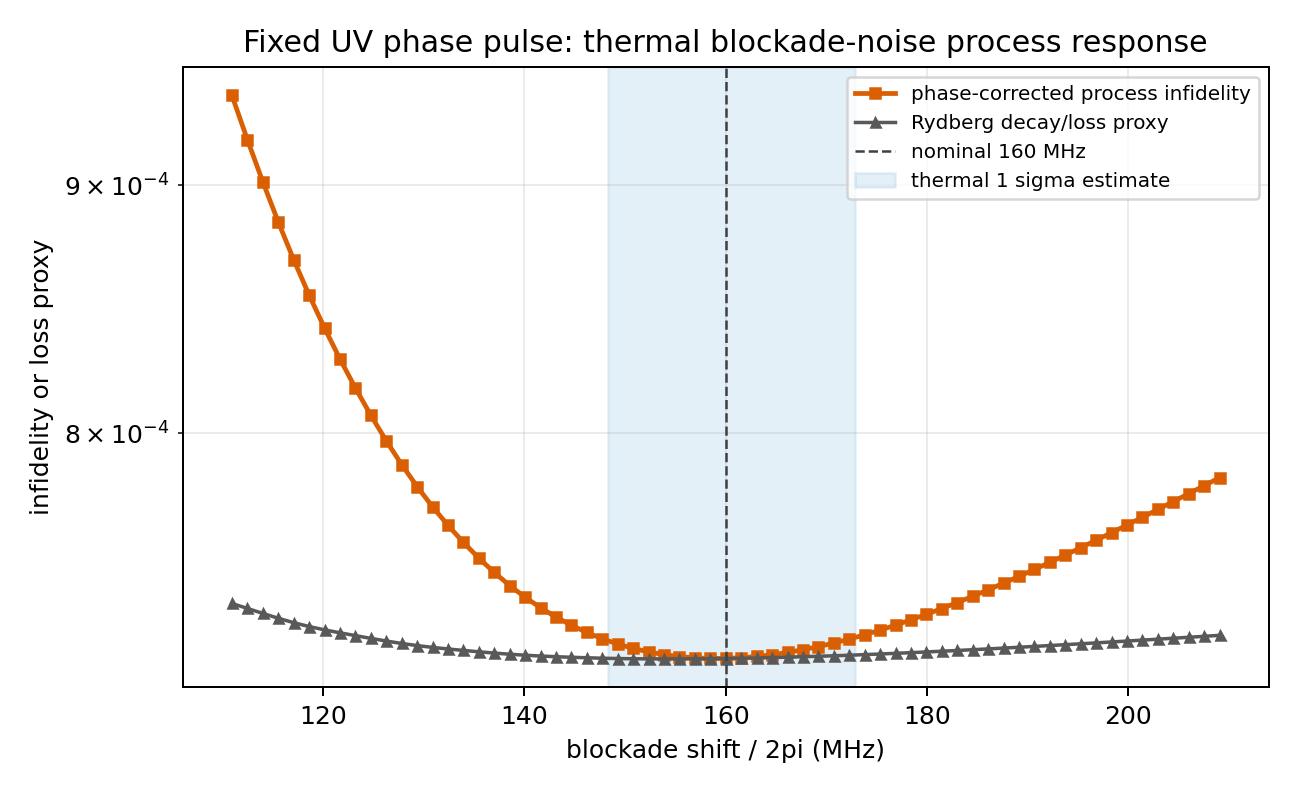

Saved plot: artifacts/v5/uv_thermal_blockade_noise_response_20260603/thermal_blockade_process_fidelity_response.png
Updated compatibility plot: artifacts/v5/uv_thermal_blockade_noise_response_20260603/thermal_blockade_fixed_phase_response.png


In [12]:
response_png = ARTIFACT_DIR / "thermal_blockade_process_fidelity_response.png"
blockades = np.array([row["blockade_shift_mhz"] for row in rows])
process_infid = 1.0 - np.array([row["process_fidelity"] for row in rows])
decay_loss_proxy = 1.0 - np.array([row["active_population"] for row in rows])
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(blockades, process_infid, marker="s", ms=3.8, lw=1.9, color="#d95f02", label="phase-corrected process infidelity")
ax.plot(blockades, decay_loss_proxy, marker="^", ms=3.6, lw=1.4, color="0.35", label="Rydberg decay/loss proxy")
ax.axvline(CONFIG.nominal_blockade_shift_mhz, color="0.25", ls="--", lw=1.0, label="nominal 160 MHz")
ax.axvspan(scales["blockade_1sigma_lower_exact_mhz"], scales["blockade_1sigma_upper_exact_mhz"], color="#6baed6", alpha=0.18, label="thermal 1 sigma estimate")
ax.set_yscale("log")
ax.set_xlabel("blockade shift / 2pi (MHz)")
ax.set_ylabel("infidelity or loss proxy")
ax.set_title("Fixed UV phase pulse: thermal blockade-noise process response")
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(response_png, dpi=180)
fig.savefig(ARTIFACT_DIR / "thermal_blockade_fixed_phase_response.png", dpi=180)
plt.show()
print(f"Saved plot: {response_png}")
print(f"Updated compatibility plot: {ARTIFACT_DIR / 'thermal_blockade_fixed_phase_response.png'}")


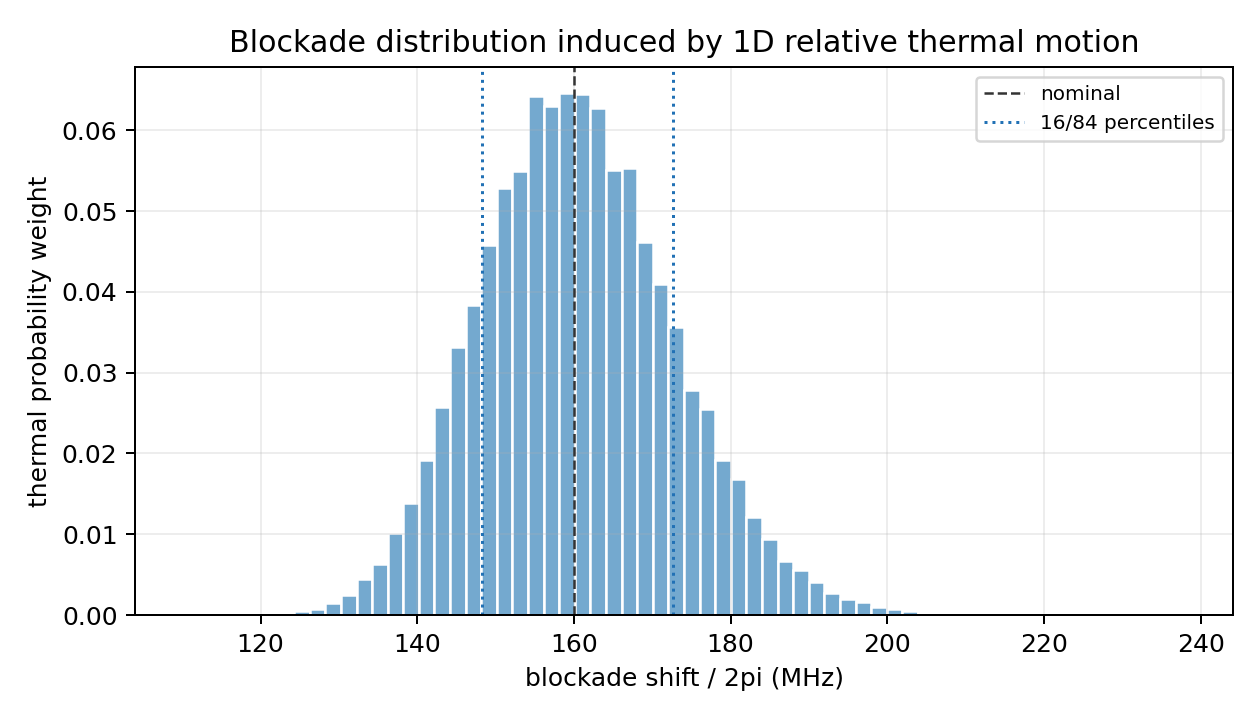

Saved plot: artifacts/v5/uv_thermal_blockade_noise_response_20260603/thermal_blockade_distribution_estimate.png


In [13]:
distribution_png = ARTIFACT_DIR / "thermal_blockade_distribution_estimate.png"
fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.hist(thermal_blockades, bins=64, weights=thermal_weights, color="#74a9cf", edgecolor="white")
ax.axvline(CONFIG.nominal_blockade_shift_mhz, color="0.2", ls="--", lw=1.0, label="nominal")
ax.axvline(thermal_summary["thermal_blockade_p16_mhz"], color="#2171b5", ls=":", lw=1.2, label="16/84 percentiles")
ax.axvline(thermal_summary["thermal_blockade_p84_mhz"], color="#2171b5", ls=":", lw=1.2)
ax.set_xlabel("blockade shift / 2pi (MHz)")
ax.set_ylabel("thermal probability weight")
ax.set_title("Blockade distribution induced by 1D relative thermal motion")
ax.grid(True, alpha=0.22)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(distribution_png, dpi=180)
plt.show()
print(f"Saved plot: {distribution_png}")


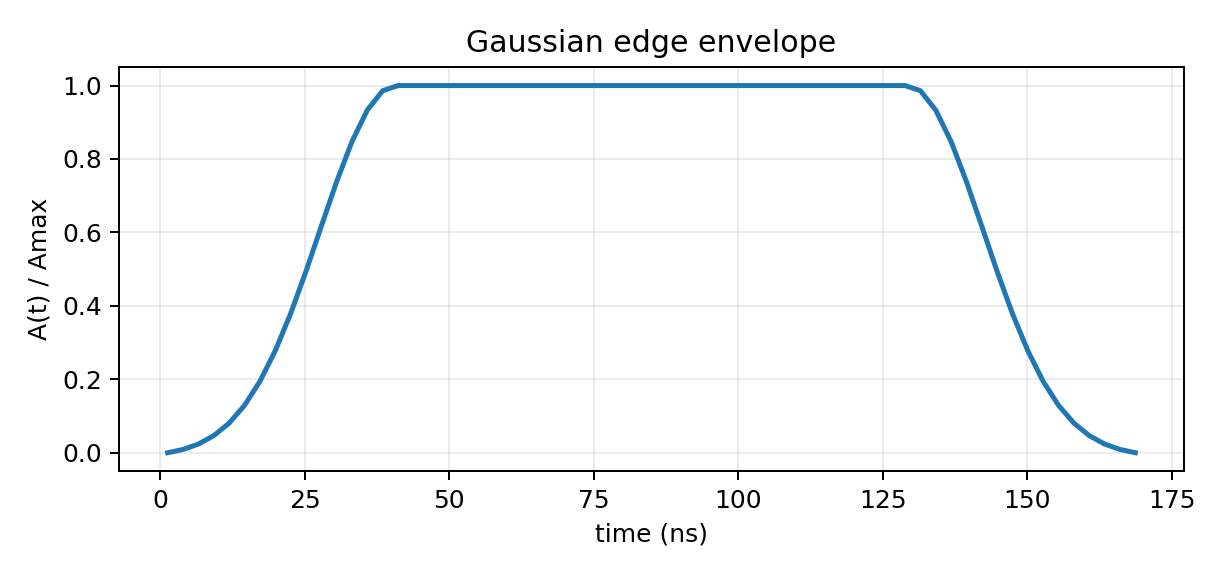

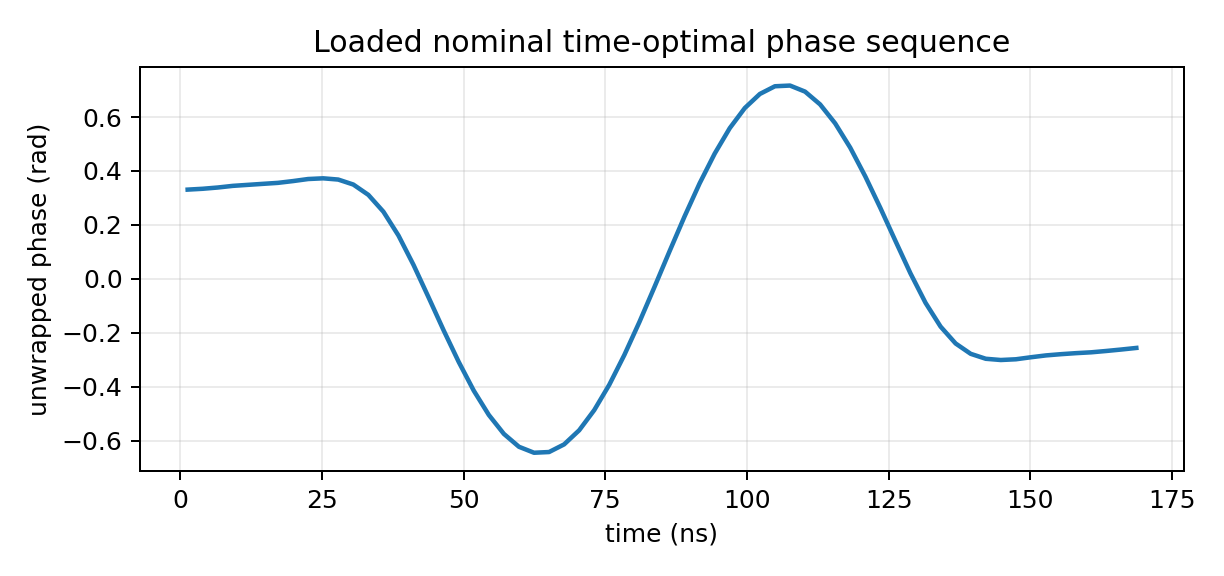

Saved envelope: artifacts/v5/uv_thermal_blockade_noise_response_20260603/gaussian_edge_envelope_nominal.png
Saved phase:    artifacts/v5/uv_thermal_blockade_noise_response_20260603/nominal_timeoptimal_phase_trace.png


In [14]:
envelope_png = ARTIFACT_DIR / "gaussian_edge_envelope_nominal.png"
phase_png = ARTIFACT_DIR / "nominal_timeoptimal_phase_trace.png"
time_axis = (np.arange(CONFIG.num_tslots) + 0.5) * CONFIG.total_time_ns / CONFIG.num_tslots
fig, ax = plt.subplots(figsize=(6.8, 3.2))
ax.plot(time_axis, nominal_model.envelope, lw=2.0)
ax.set_xlabel("time (ns)")
ax.set_ylabel("A(t) / Amax")
ax.set_title("Gaussian edge envelope")
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(envelope_png, dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(6.8, 3.2))
ax.plot(time_axis, unwrap_for_plot(nominal_phases), lw=1.8)
ax.set_xlabel("time (ns)")
ax.set_ylabel("unwrapped phase (rad)")
ax.set_title("Loaded nominal time-optimal phase sequence")
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(phase_png, dpi=180)
plt.show()
print(f"Saved envelope: {envelope_png}")
print(f"Saved phase:    {phase_png}")


## Doppler effect as an explicit function of temperature

Li, Qian, and Zhang model residual motional dephasing as a quasistatic Doppler detuning. A moving atom with velocity `v` sees

$$
\delta = \mathbf{k}\cdot\mathbf{v},
$$

and the Hamiltonian contains

$$
H_D = -\delta |r\rangle\langle r|.
$$

Their ensemble model uses a one-dimensional Gaussian velocity distribution. Written directly in terms of temperature,

$$
\sigma_v^2(T)=\frac{k_B T}{m}.
$$

For the current one-photon UV excitation,

$$
k_\mathrm{UV}=\frac{2\pi}{\lambda},\qquad
\lambda=301.9\,\mathrm{nm}.
$$

The single-atom Doppler RMS is therefore

$$
\frac{\sigma_\delta(T)}{2\pi}
=\frac{\sigma_v(T)}{\lambda}
=
23.097\sqrt{T_{\mu\mathrm{K}}}\,\mathrm{kHz}.
$$

At the optional reference temperature inferred from `\bar n=0.25`,

$$
T_\mathrm{ref}=1.49\,\mu\mathrm{K},
\qquad
\frac{\sigma_\delta}{2\pi}=28.20\,\mathrm{kHz}.
$$

This is small compared with `\Omega/2\pi=10 MHz`:

$$
\frac{\sigma_\delta}{\Omega}
=2.82\times10^{-3}
\quad (T=1.49\,\mu\mathrm{K}).
$$

If a state remained in `|r\rangle` for the full `170 ns` gate duration, the RMS phase would be

$$
\sigma_\phi(T)
=2\pi\frac{\sigma_\delta(T)}{2\pi}T_g
=0.02469\sqrt{T_{\mu\mathrm{K}}}\,\mathrm{rad}.
$$

At `T_ref`, this gives `0.0301 rad`.

### Two-atom decomposition

For two atoms,

$$
\delta_i = k_\mathrm{UV}v_i,\qquad i=1,2.
$$

The double-Rydberg branch sees `\delta_1+\delta_2`, so

$$
\frac{\sigma_{rr}(T)}{2\pi}
=\sqrt{2}\frac{\sigma_\delta(T)}{2\pi}.
$$

For the one-Rydberg pair states, define

$$
\delta_c=\frac{\delta_1+\delta_2}{2},\qquad
\delta_d=\frac{\delta_1-\delta_2}{2}.
$$

Then

$$
\frac{\sigma_{\delta_c}(T)}{2\pi}
=
\frac{\sigma_{\delta_d}(T)}{2\pi}
=
\frac{1}{\sqrt{2}}\frac{\sigma_\delta(T)}{2\pi}
=16.332\sqrt{T_{\mu\mathrm{K}}}\,\mathrm{kHz}.
$$

At `T_ref`, the common and differential RMS detunings are both `19.94 kHz`, while the double-Rydberg sum RMS is `39.88 kHz`.

In the symmetric/antisymmetric basis,

$$
|W\rangle=\frac{|cr\rangle+|rc\rangle}{\sqrt{2}},\qquad
|A\rangle=\frac{|cr\rangle-|rc\rangle}{\sqrt{2}},
$$

the Doppler Hamiltonian contains

$$
H_D =
-\delta_c\left(|W\rangle\langle W|+|A\rangle\langle A|\right)
-\delta_d\left(|W\rangle\langle A|+|A\rangle\langle W|\right).
$$

Thus the current six-state symmetric model can evaluate common-mode Doppler detuning, but a complete independent-velocity simulation requires adding the antisymmetric `|A\rangle` sector.


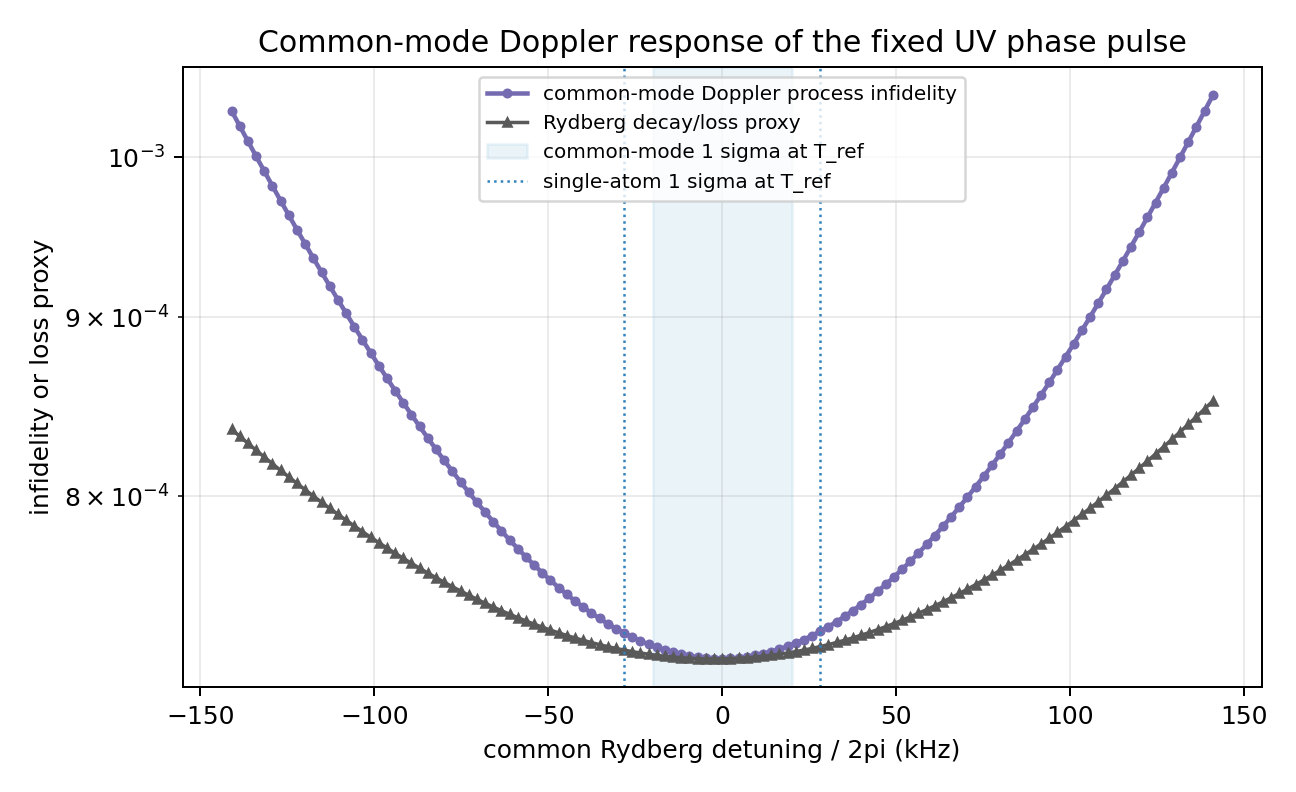

{
  "temperature_source": "inferred from reported nbar using Bose-Einstein oscillator relation",
  "reference_temperature_uK": 1.4909686895492906,
  "nbar_used_for_reference": 0.25,
  "sigma_velocity_m_per_s": 0.008514385294874896,
  "k_uv_per_um": 20.81214079887243,
  "single_atom_sigma_delta_over_2pi_khz": 28.20266742257336,
  "common_mode_sigma_delta_over_2pi_khz": 19.94229738205055,
  "differential_sigma_delta_over_2pi_khz": 19.94229738205055,
  "double_rydberg_sum_sigma_delta_over_2pi_khz": 39.88459476410111,
  "single_atom_sigma_delta_over_2pi_khz_per_sqrt_uK": 23.09701861606123,
  "common_mode_sigma_delta_over_2pi_khz_per_sqrt_uK": 16.332058488608823,
  "double_rydberg_sum_sigma_delta_over_2pi_khz_per_sqrt_uK": 32.66411697721765,
  "sigma_delta_over_omega": 0.002820266742257336,
  "full_gate_single_rydberg_rms_phase_rad": 0.0301244395473735,
  "full_gate_single_rydberg_rms_phase_rad_per_sqrt_uK": 0.024670884161375185,
  "common_mode_average_process_fidelity": 0.9992746788303174,

In [15]:
doppler_json = ARTIFACT_DIR / "thermal_doppler_estimate.json"
doppler_response_png = ARTIFACT_DIR / "thermal_doppler_common_mode_response.png"

k_b = 1.380649e-23
atomic_mass_unit_kg = 1.66053906660e-27
mass_kg = CONFIG.atom_mass_amu * atomic_mass_unit_kg
lambda_uv_m = CONFIG.uv_wavelength_nm * 1e-9
k_uv = 2.0 * np.pi / lambda_uv_m
temperature_k = reference_temperature_uK * 1e-6

sigma_v = np.sqrt(k_b * temperature_k / mass_kg)
sigma_delta_hz = sigma_v / lambda_uv_m
sigma_delta_common_hz = sigma_delta_hz / np.sqrt(2.0)
sigma_delta_differential_hz = sigma_delta_hz / np.sqrt(2.0)
sigma_delta_rr_sum_hz = np.sqrt(2.0) * sigma_delta_hz
full_gate_rms_phase_rad = 2.0 * np.pi * sigma_delta_hz * CONFIG.total_time_ns * 1e-9
doppler_khz_per_sqrt_uK = np.sqrt(k_b * 1e-6 / mass_kg) / lambda_uv_m / 1e3
common_khz_per_sqrt_uK = doppler_khz_per_sqrt_uK / np.sqrt(2.0)
rr_khz_per_sqrt_uK = np.sqrt(2.0) * doppler_khz_per_sqrt_uK
full_gate_phase_per_sqrt_uK = 2.0 * np.pi * doppler_khz_per_sqrt_uK * 1e3 * CONFIG.total_time_ns * 1e-9

doppler_grid_khz = np.linspace(-5.0 * sigma_delta_hz / 1e3, 5.0 * sigma_delta_hz / 1e3, 121)
doppler_rows = []
for detuning_khz in doppler_grid_khz:
    model = ShelvedCRUVNoJumpModel(
        CONFIG,
        CONFIG.nominal_blockade_shift_mhz,
        common_rydberg_detuning_mhz=float(detuning_khz * 1e-3),
    )
    z_diag = model.z_diagonal(nominal_phases)
    corrected = fit_virtual_z_phases(z_diag, nominal_alpha, nominal_beta)
    doppler_rows.append(
        {
            "common_detuning_khz": float(detuning_khz),
            "process_fidelity": float(corrected["process_fidelity"]),
            "active_population": float(corrected["active_population"]),
            "process_infidelity": float(1.0 - corrected["process_fidelity"]),
            "loss_proxy": float(1.0 - corrected["active_population"]),
        }
    )

def gaussian_weighted_average(values: np.ndarray, grid_khz: np.ndarray, sigma_khz: float) -> float:
    weights = np.exp(-0.5 * (grid_khz / sigma_khz) ** 2)
    weights /= float(np.sum(weights))
    return float(np.sum(weights * values))

grid = np.array([row["common_detuning_khz"] for row in doppler_rows])
process_values = np.array([row["process_fidelity"] for row in doppler_rows])
loss_values = np.array([row["loss_proxy"] for row in doppler_rows])

doppler_summary = {
    "temperature_source": "inferred from reported nbar using Bose-Einstein oscillator relation",
    "reference_temperature_uK": float(reference_temperature_uK),
    "nbar_used_for_reference": CONFIG.mean_motional_occupation,
    "sigma_velocity_m_per_s": float(sigma_v),
    "k_uv_per_um": float(k_uv / 1e6),
    "single_atom_sigma_delta_over_2pi_khz": float(sigma_delta_hz / 1e3),
    "common_mode_sigma_delta_over_2pi_khz": float(sigma_delta_common_hz / 1e3),
    "differential_sigma_delta_over_2pi_khz": float(sigma_delta_differential_hz / 1e3),
    "double_rydberg_sum_sigma_delta_over_2pi_khz": float(sigma_delta_rr_sum_hz / 1e3),
    "single_atom_sigma_delta_over_2pi_khz_per_sqrt_uK": float(doppler_khz_per_sqrt_uK),
    "common_mode_sigma_delta_over_2pi_khz_per_sqrt_uK": float(common_khz_per_sqrt_uK),
    "double_rydberg_sum_sigma_delta_over_2pi_khz_per_sqrt_uK": float(rr_khz_per_sqrt_uK),
    "sigma_delta_over_omega": float(sigma_delta_hz / (CONFIG.omega_max_mhz * 1e6)),
    "full_gate_single_rydberg_rms_phase_rad": float(full_gate_rms_phase_rad),
    "full_gate_single_rydberg_rms_phase_rad_per_sqrt_uK": float(full_gate_phase_per_sqrt_uK),
    "common_mode_average_process_fidelity": gaussian_weighted_average(
        process_values,
        grid,
        sigma_delta_common_hz / 1e3,
    ),
    "conservative_single_atom_sigma_common_detuning_average_process_fidelity": gaussian_weighted_average(
        process_values,
        grid,
        sigma_delta_hz / 1e3,
    ),
    "common_mode_average_loss_proxy": gaussian_weighted_average(
        loss_values,
        grid,
        sigma_delta_common_hz / 1e3,
    ),
}

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(grid, 1.0 - process_values, marker="o", ms=3.0, lw=1.8, color="#756bb1", label="common-mode Doppler process infidelity")
ax.plot(grid, loss_values, marker="^", ms=3.0, lw=1.4, color="0.35", label="Rydberg decay/loss proxy")
ax.axvspan(-sigma_delta_common_hz / 1e3, sigma_delta_common_hz / 1e3, color="#9ecae1", alpha=0.22, label="common-mode 1 sigma at T_ref")
ax.axvline(-sigma_delta_hz / 1e3, color="#3182bd", ls=":", lw=1.0, label="single-atom 1 sigma at T_ref")
ax.axvline(sigma_delta_hz / 1e3, color="#3182bd", ls=":", lw=1.0)
ax.set_yscale("log")
ax.set_xlabel("common Rydberg detuning / 2pi (kHz)")
ax.set_ylabel("infidelity or loss proxy")
ax.set_title("Common-mode Doppler response of the fixed UV phase pulse")
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(doppler_response_png, dpi=180)
plt.show()

doppler_json.write_text(
    json.dumps(
        {
            "source": {
                "zotero_item_key": "IK4SLCXW",
                "zotero_attachment_key": "CCXS3N3C",
                "doi": "10.1088/1367-2630/adcfbe",
                "title": "Erasing Doppler dephasing error in Rydberg quantum gates",
                "authors": ["Rui Li", "Jing Qian", "Weiping Zhang"],
                "journal": "New Journal of Physics",
                "year": 2025,
            },
            "config": asdict(CONFIG),
            "temperature_reference": {
                "source": "inferred from reported nbar using Bose-Einstein oscillator relation",
                "nbar": CONFIG.mean_motional_occupation,
                "reference_temperature_uK": reference_temperature_uK,
            },
            "doppler_summary": doppler_summary,
            "common_mode_response_rows": doppler_rows,
            "model_limitations": [
                "The current 6D symmetric model includes common Doppler detuning only.",
                "Independent atom velocities also produce differential Doppler coupling from the symmetric |W_cr> state to an antisymmetric state not present in this notebook basis.",
            ],
        },
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

print(json.dumps(doppler_summary, indent=2))
print(f"Saved Doppler estimate: {doppler_json}")
print(f"Saved Doppler response plot: {doppler_response_png}")



## Temperature scan: sampled thermal blockade and Doppler infidelity

The previous sections evaluate the blockade response and the common-mode Doppler response separately. This cell turns those response functions into a small temperature scan while keeping the same optimized UV phase sequence.

For each temperature, draw reproducible Gaussian samples for:

- relative position fluctuation `q`, mapped through `B(q)=B_0/(1+q/R)^6`;
- common-mode Doppler detuning, with RMS `sigma_delta_common/sqrt(2pi)=sigma_delta_single/sqrt(2)`.

The table reports both the sampled average process infidelity including the nominal decay/edge baseline and the excess over the nominal decay+Gaussian-edge infidelity. The thermal-effect estimate is the sum of the two excess terms, so the decay baseline is not double counted.


T_uK    blockade_excess    doppler_excess     thermal_sum       total_with_decay
 0.100     1.252095e-06     9.502613e-07     2.202357e-06     7.211791e-04
 0.250     3.070325e-06     2.334205e-06     5.404530e-06     7.243813e-04
 0.500     6.106281e-06     4.640152e-06     1.074643e-05     7.297232e-04
 1.000     1.220602e-05     9.251948e-06     2.145797e-05     7.404347e-04
 1.491     1.823077e-05     1.377979e-05     3.201055e-05     7.509873e-04
 2.000     2.451334e-05     1.847423e-05     4.298758e-05     7.619643e-04
 3.000     3.696298e-05     2.769661e-05     6.465959e-05     7.836363e-04
 5.000     6.227282e-05     4.613965e-05     1.084125e-04     8.273892e-04
10.000     1.279444e-04     9.224021e-05     2.201846e-04     9.391613e-04
Saved temperature scan CSV:  artifacts/v5/uv_thermal_blockade_noise_response_20260603/thermal_temperature_scan.csv
Saved temperature scan JSON: artifacts/v5/uv_thermal_blockade_noise_response_20260603/thermal_temperature_scan.json
Saved tempera

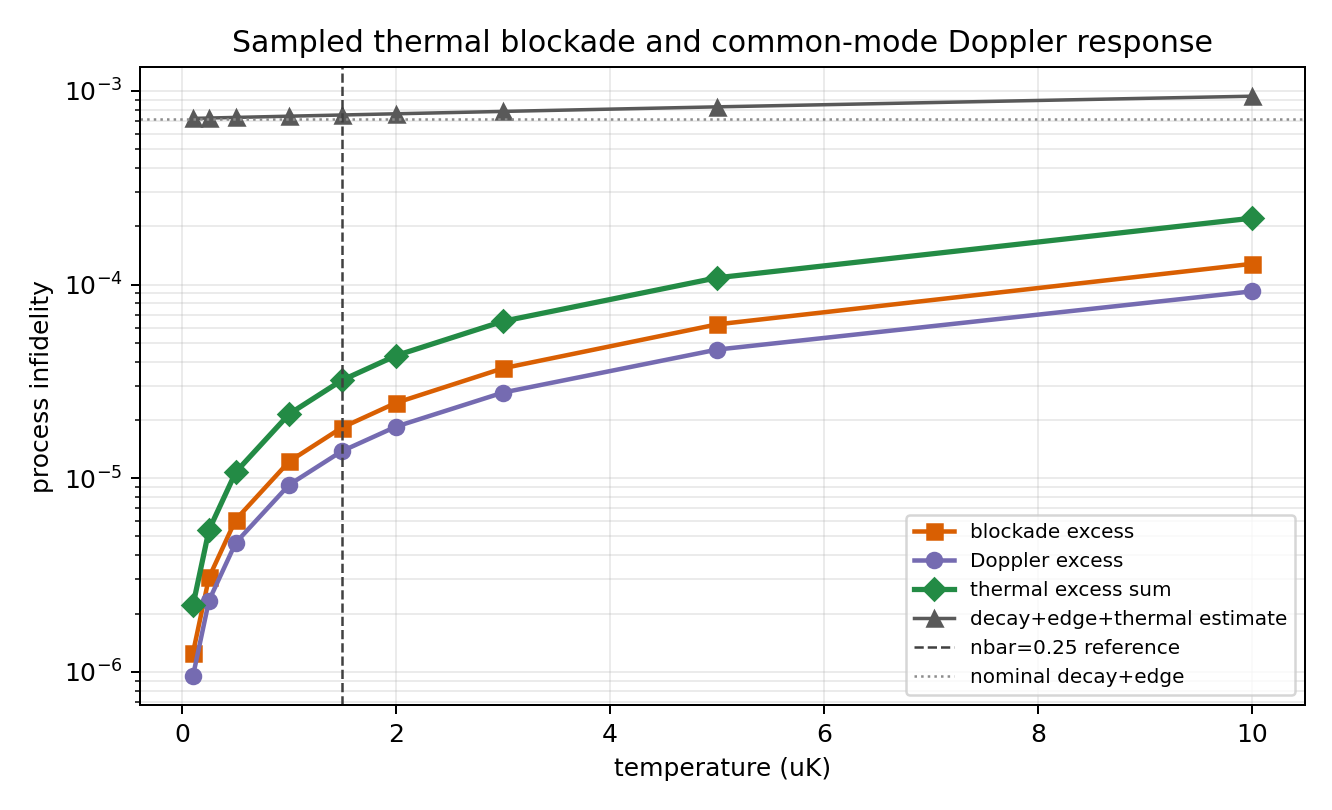

In [17]:

temperature_scan_uK = np.array(
    [0.10, 0.25, 0.50, 1.00, reference_temperature_uK, 2.00, 3.00, 5.00, 10.00],
    dtype=np.float64,
)
temperature_scan_uK = np.array(sorted({round(float(value), 12) for value in temperature_scan_uK}), dtype=np.float64)
temperature_scan_samples = 4096
temperature_scan_seed = 17120260603
temperature_scan_rng = np.random.default_rng(temperature_scan_seed)
position_standard_samples = temperature_scan_rng.normal(size=temperature_scan_samples)
doppler_standard_samples = temperature_scan_rng.normal(size=temperature_scan_samples)


def blockade_from_relative_position_m(relative_position_m: np.ndarray, config: ThermalBlockadeConfig) -> np.ndarray:
    spacing_m = config.pair_spacing_um * 1e-6
    return config.nominal_blockade_shift_mhz / (1.0 + relative_position_m / spacing_m) ** 6


def response_at_blockade_fixed_virtual_z(blockade_mhz: float) -> dict[str, float]:
    model = ShelvedCRUVNoJumpModel(CONFIG, float(blockade_mhz))
    z_diag = model.z_diagonal(nominal_phases)
    process_fidelity, active_population, average_fidelity = no_jump_metrics_from_z(
        z_diag,
        nominal_alpha,
        nominal_beta,
    )
    return {
        "blockade_shift_mhz": float(blockade_mhz),
        "process_fidelity": float(process_fidelity),
        "process_infidelity": float(1.0 - process_fidelity),
        "active_population": float(active_population),
        "loss_proxy": float(1.0 - active_population),
        "no_jump_average_fidelity": float(average_fidelity),
    }


def response_at_common_doppler_fixed_virtual_z(detuning_khz: float) -> dict[str, float]:
    model = ShelvedCRUVNoJumpModel(
        CONFIG,
        CONFIG.nominal_blockade_shift_mhz,
        common_rydberg_detuning_mhz=float(detuning_khz) * 1e-3,
    )
    z_diag = model.z_diagonal(nominal_phases)
    process_fidelity, active_population, average_fidelity = no_jump_metrics_from_z(
        z_diag,
        nominal_alpha,
        nominal_beta,
    )
    return {
        "common_detuning_khz": float(detuning_khz),
        "process_fidelity": float(process_fidelity),
        "process_infidelity": float(1.0 - process_fidelity),
        "active_population": float(active_population),
        "loss_proxy": float(1.0 - active_population),
        "no_jump_average_fidelity": float(average_fidelity),
    }


blockade_samples_by_temperature: dict[float, np.ndarray] = {}
doppler_samples_by_temperature: dict[float, np.ndarray] = {}
thermal_scale_rows: dict[float, dict[str, float]] = {}
position_clip_fraction_by_temperature: dict[float, float] = {}

spacing_m = CONFIG.pair_spacing_um * 1e-6
for temperature_uK in temperature_scan_uK:
    scan_scales = thermal_motion_scales(CONFIG, float(temperature_uK))
    thermal_scale_rows[float(temperature_uK)] = scan_scales
    relative_position_m = position_standard_samples * scan_scales["sigma_relative_position_nm"] * 1e-9
    clipped_relative_position_m = np.clip(relative_position_m, -0.45 * spacing_m, 0.45 * spacing_m)
    position_clip_fraction_by_temperature[float(temperature_uK)] = float(
        np.mean(clipped_relative_position_m != relative_position_m)
    )
    blockade_samples_by_temperature[float(temperature_uK)] = blockade_from_relative_position_m(
        clipped_relative_position_m,
        CONFIG,
    )
    common_sigma_khz = scan_scales["doppler_single_atom_rms_hz"] / 1e3 / np.sqrt(2.0)
    doppler_samples_by_temperature[float(temperature_uK)] = doppler_standard_samples * common_sigma_khz

all_blockade_samples = np.concatenate(list(blockade_samples_by_temperature.values()))
all_doppler_samples = np.concatenate(list(doppler_samples_by_temperature.values()))
blockade_min = float(np.min(all_blockade_samples))
blockade_max = float(np.max(all_blockade_samples))
doppler_abs_max = float(np.max(np.abs(all_doppler_samples)))

blockade_response_grid_mhz = np.unique(
    np.concatenate(
        [
            np.linspace(blockade_min, blockade_max, 181),
            np.array([CONFIG.nominal_blockade_shift_mhz], dtype=np.float64),
        ]
    )
)
doppler_response_grid_khz = np.unique(
    np.concatenate(
        [
            np.linspace(-doppler_abs_max, doppler_abs_max, 181),
            np.array([0.0], dtype=np.float64),
        ]
    )
)

temperature_blockade_response_rows = [
    response_at_blockade_fixed_virtual_z(float(blockade_mhz))
    for blockade_mhz in blockade_response_grid_mhz
]
temperature_doppler_response_rows = [
    response_at_common_doppler_fixed_virtual_z(float(detuning_khz))
    for detuning_khz in doppler_response_grid_khz
]

blockade_grid = np.array([row["blockade_shift_mhz"] for row in temperature_blockade_response_rows])
blockade_infidelity_grid = np.array([row["process_infidelity"] for row in temperature_blockade_response_rows])
blockade_loss_grid = np.array([row["loss_proxy"] for row in temperature_blockade_response_rows])
doppler_grid = np.array([row["common_detuning_khz"] for row in temperature_doppler_response_rows])
doppler_infidelity_grid = np.array([row["process_infidelity"] for row in temperature_doppler_response_rows])
doppler_loss_grid = np.array([row["loss_proxy"] for row in temperature_doppler_response_rows])

nominal_process_infidelity = float(1.0 - nominal_metrics[0])
nominal_loss_proxy = float(1.0 - nominal_metrics[1])

temperature_scan_rows = []
for temperature_uK in temperature_scan_uK:
    key = float(temperature_uK)
    sampled_blockade = blockade_samples_by_temperature[key]
    sampled_doppler = doppler_samples_by_temperature[key]
    sampled_blockade_infidelity = np.interp(sampled_blockade, blockade_grid, blockade_infidelity_grid)
    sampled_blockade_loss = np.interp(sampled_blockade, blockade_grid, blockade_loss_grid)
    sampled_doppler_infidelity = np.interp(sampled_doppler, doppler_grid, doppler_infidelity_grid)
    sampled_doppler_loss = np.interp(sampled_doppler, doppler_grid, doppler_loss_grid)

    blockade_average_infidelity = float(np.mean(sampled_blockade_infidelity))
    doppler_average_infidelity = float(np.mean(sampled_doppler_infidelity))
    blockade_excess = blockade_average_infidelity - nominal_process_infidelity
    doppler_excess = doppler_average_infidelity - nominal_process_infidelity
    thermal_excess_sum = blockade_excess + doppler_excess
    scales_for_temperature = thermal_scale_rows[key]
    temperature_scan_rows.append(
        {
            "temperature_uK": key,
            "samples": int(temperature_scan_samples),
            "nominal_decay_edge_process_infidelity": nominal_process_infidelity,
            "blockade_average_process_infidelity_including_decay": blockade_average_infidelity,
            "doppler_average_process_infidelity_including_decay": doppler_average_infidelity,
            "blockade_excess_process_infidelity_over_nominal_decay_edge": float(blockade_excess),
            "doppler_excess_process_infidelity_over_nominal_decay_edge": float(doppler_excess),
            "thermal_effect_excess_process_infidelity_sum": float(thermal_excess_sum),
            "estimated_total_process_infidelity_decay_edge_plus_thermal_sum": float(
                nominal_process_infidelity + thermal_excess_sum
            ),
            "blockade_process_infidelity_standard_error": float(
                np.std(sampled_blockade_infidelity, ddof=1) / np.sqrt(temperature_scan_samples)
            ),
            "doppler_process_infidelity_standard_error": float(
                np.std(sampled_doppler_infidelity, ddof=1) / np.sqrt(temperature_scan_samples)
            ),
            "blockade_average_loss_proxy": float(np.mean(sampled_blockade_loss)),
            "doppler_average_loss_proxy": float(np.mean(sampled_doppler_loss)),
            "nominal_loss_proxy": nominal_loss_proxy,
            "sigma_relative_position_nm": float(scales_for_temperature["sigma_relative_position_nm"]),
            "blockade_sigma_mhz_linear": float(scales_for_temperature["blockade_sigma_mhz_linear"]),
            "common_mode_doppler_sigma_over_2pi_khz": float(
                scales_for_temperature["doppler_single_atom_rms_hz"] / 1e3 / np.sqrt(2.0)
            ),
            "position_clip_fraction": position_clip_fraction_by_temperature[key],
        }
    )

temperature_scan_csv = ARTIFACT_DIR / "thermal_temperature_scan.csv"
temperature_scan_json = ARTIFACT_DIR / "thermal_temperature_scan.json"
temperature_scan_png = ARTIFACT_DIR / "thermal_temperature_scan_infidelity_components.png"

with temperature_scan_csv.open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(temperature_scan_rows[0].keys()))
    writer.writeheader()
    writer.writerows(temperature_scan_rows)

temperature_scan_json.write_text(
    json.dumps(
        {
            "config": asdict(CONFIG),
            "phase_source_note": phase_source_note,
            "sampling": {
                "seed": temperature_scan_seed,
                "samples_per_temperature": temperature_scan_samples,
                "temperatures_uK": [float(value) for value in temperature_scan_uK],
                "position_distribution": "1D Gaussian relative coordinate mapped through B(q)=B0/(1+q/R)^6",
                "doppler_distribution": "1D Gaussian common-mode Doppler detuning in current symmetric 6D model",
                "component_definition": "excess process infidelity relative to nominal decay+Gaussian-edge optimized fixed phase sequence",
            },
            "nominal": {
                "process_fidelity": float(nominal_metrics[0]),
                "process_infidelity": nominal_process_infidelity,
                "active_population": float(nominal_metrics[1]),
                "loss_proxy": nominal_loss_proxy,
                "alpha": nominal_alpha,
                "beta": nominal_beta,
            },
            "temperature_scan_rows": temperature_scan_rows,
            "blockade_response_grid_rows": temperature_blockade_response_rows,
            "doppler_response_grid_rows": temperature_doppler_response_rows,
            "model_limitations": [
                "Thermal blockade and Doppler terms are averaged separately and then added at first order.",
                "The Doppler response uses common-mode detuning only; independent-velocity differential coupling to the antisymmetric single-Rydberg state is not included in this 6D symmetric basis.",
                "The fixed nominal virtual-Z phases are used for each noise sample, because random thermal shifts are not assumed to be known shot by shot.",
            ],
        },
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)

temperatures = np.array([row["temperature_uK"] for row in temperature_scan_rows])
blockade_excess_values = np.array(
    [row["blockade_excess_process_infidelity_over_nominal_decay_edge"] for row in temperature_scan_rows]
)
doppler_excess_values = np.array(
    [row["doppler_excess_process_infidelity_over_nominal_decay_edge"] for row in temperature_scan_rows]
)
thermal_sum_values = np.array(
    [row["thermal_effect_excess_process_infidelity_sum"] for row in temperature_scan_rows]
)
estimated_total_values = np.array(
    [row["estimated_total_process_infidelity_decay_edge_plus_thermal_sum"] for row in temperature_scan_rows]
)

fig, ax = plt.subplots(figsize=(7.4, 4.5))
ax.plot(temperatures, blockade_excess_values, marker="s", lw=1.8, color="#d95f02", label="blockade excess")
ax.plot(temperatures, doppler_excess_values, marker="o", lw=1.8, color="#756bb1", label="Doppler excess")
ax.plot(temperatures, thermal_sum_values, marker="D", lw=2.1, color="#238b45", label="thermal excess sum")
ax.plot(temperatures, estimated_total_values, marker="^", lw=1.4, color="0.35", label="decay+edge+thermal estimate")
ax.axvline(reference_temperature_uK, color="0.25", ls="--", lw=1.0, label="nbar=0.25 reference")
ax.axhline(nominal_process_infidelity, color="0.55", ls=":", lw=1.0, label="nominal decay+edge")
if np.all(np.concatenate([blockade_excess_values, doppler_excess_values, thermal_sum_values, estimated_total_values]) > 0.0):
    ax.set_yscale("log")
else:
    ax.axhline(0.0, color="0.5", lw=0.8)
ax.set_xlabel("temperature (uK)")
ax.set_ylabel("process infidelity")
ax.set_title("Sampled thermal blockade and common-mode Doppler response")
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(temperature_scan_png, dpi=180)
plt.show()

print("T_uK    blockade_excess    doppler_excess     thermal_sum       total_with_decay")
for row in temperature_scan_rows:
    print(
        f"{row['temperature_uK']:6.3f}  "
        f"{row['blockade_excess_process_infidelity_over_nominal_decay_edge']:15.6e}  "
        f"{row['doppler_excess_process_infidelity_over_nominal_decay_edge']:15.6e}  "
        f"{row['thermal_effect_excess_process_infidelity_sum']:15.6e}  "
        f"{row['estimated_total_process_infidelity_decay_edge_plus_thermal_sum']:15.6e}"
    )
print(f"Saved temperature scan CSV:  {temperature_scan_csv}")
print(f"Saved temperature scan JSON: {temperature_scan_json}")
print(f"Saved temperature scan plot: {temperature_scan_png}")


## Validation and first-pass interpretation

Validation checks:

- Re-evaluate the nominal `160 MHz` selected phase row with the notebook-local model.
- Confirm that the mismatch from the source selected artifact is numerical roundoff rather than a unit or basis error.
- Save machine-readable JSON/CSV next to human-readable plots.
- Read Li, Qian, and Zhang 2025 from Zotero and use their `\delta=\mathbf{k}\cdot\mathbf{v}` Doppler-detuning model for the Doppler scale estimate.

First-pass result: the final thermal formulas are explicit functions of temperature `T`. The reported `\bar n=0.25` only gives an optional reference temperature `T_ref=1.49 uK`. At that reference point, the phase-corrected process fidelity remains close to the nominal decay-limited value for blockade fluctuations, and the single-atom UV Doppler RMS is `28.2 kHz`. The common-mode Doppler response is evaluated here; a complete independent-velocity Doppler simulation needs the antisymmetric single-Rydberg sector.


In [18]:

print(f"phase source: {phase_source_note}")
print(f"nominal selected process fidelity: {float(nominal_row['process_fidelity']):.12f}")
print(f"notebook-local nominal process fidelity: {nominal_metrics[0]:.12f}")
print(f"absolute mismatch: {abs(float(nominal_row['process_fidelity']) - nominal_metrics[0]):.3e}")
print(f"reference temperature from nbar: {reference_temperature_uK:.3f} uK")
print(f"sigma_B/h coefficient: {scales['blockade_sigma_mhz_per_sqrt_uK']:.3f} MHz/sqrt(uK)")
print(f"thermal sigma_B/h at T_ref: {scales['blockade_sigma_mhz_linear']:.3f} MHz")
if 'thermal_summary' in globals():
    print(f"thermal averaged process fidelity at T_ref: {thermal_summary['thermal_average_process_fidelity']:.12f}")
if 'doppler_summary' in globals():
    print(f"single-atom Doppler RMS coefficient: {doppler_summary['single_atom_sigma_delta_over_2pi_khz_per_sqrt_uK']:.3f} kHz/sqrt(uK)")
    print(f"single-atom Doppler RMS at T_ref: {doppler_summary['single_atom_sigma_delta_over_2pi_khz']:.3f} kHz")
    print(f"common-mode Doppler average process fidelity at T_ref: {doppler_summary['common_mode_average_process_fidelity']:.12f}")
if 'temperature_scan_rows' in globals():
    reference_row = min(temperature_scan_rows, key=lambda row: abs(row['temperature_uK'] - reference_temperature_uK))
    print(
        "sampled thermal excess at T_ref: "
        f"blockade={reference_row['blockade_excess_process_infidelity_over_nominal_decay_edge']:.3e}, "
        f"Doppler={reference_row['doppler_excess_process_infidelity_over_nominal_decay_edge']:.3e}, "
        f"sum={reference_row['thermal_effect_excess_process_infidelity_sum']:.3e}"
    )
    hottest_row = temperature_scan_rows[-1]
    print(
        "sampled thermal excess at max scanned T: "
        f"T={hottest_row['temperature_uK']:.3f} uK, "
        f"sum={hottest_row['thermal_effect_excess_process_infidelity_sum']:.3e}, "
        f"total with decay={hottest_row['estimated_total_process_infidelity_decay_edge_plus_thermal_sum']:.3e}"
    )
print(f"artifacts: {ARTIFACT_DIR}")


phase source: loaded selected phase row from artifacts/v5/closed_cr_edge_time_optimal_scan/rydberg_decay_65us_dense_selected_phase_rows.json
nominal selected process fidelity: 0.999281023258
notebook-local nominal process fidelity: 0.999281023258
absolute mismatch: 0.000e+00
reference temperature from nbar: 1.491 uK
sigma_B/h coefficient: 10.045 MHz/sqrt(uK)
thermal sigma_B/h at T_ref: 12.265 MHz
sampled thermal excess at T_ref: blockade=1.823e-05, Doppler=1.378e-05, sum=3.201e-05
sampled thermal excess at max scanned T: T=10.000 uK, sum=2.202e-04, total with decay=9.392e-04
artifacts: artifacts/v5/uv_thermal_blockade_noise_response_20260603
